# ZTF SNIa Hubble Residuals — ML Algorithm Sampler

This notebook applies a variety of supervised machine learning regression algorithms to predict
Type Ia supernova (SNIa) Hubble residuals ($\Delta\mu$) from host galaxy properties measured
by DESI spectroscopy.

## Goals
- Reproduce the exact quality cuts from `ZTF_DESI_ml_work/ZTF_slr_result_3_rf_no_x1_c.ipynb`
- Train and evaluate **8 different ML regressors** on the cleaned ~570-SN dataset
- Compare performance metrics (MAE, RMSE, R²) across all models
- Explore and compare **feature importances** to understand what drives the Hubble residuals

## Features (9 total)
| Feature | Description |
|---|---|
| `LOGMSTAR` | Log stellar mass |
| `c` | SN colour (SALT2) |
| `x1` | SN stretch (SALT2) |
| `SFR` | Star formation rate (M☉/yr) |
| `VDISP` | Stellar velocity dispersion (km/s) |
| `DN4000` | 4000 Å break strength |
| `SDSS_g_minus_r` | Host galaxy g−r colour |
| `AGE` | Mean stellar age (Gyr) |
| `redshift` | Spectroscopic redshift |

## Target
`residual_centered` — the centered Hubble residual $\Delta\mu$ for each SN Ia

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.stats import sigma_clip

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    cross_val_predict,
    learning_curve,
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

# Tree-based models
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
)

# Linear models
from sklearn.linear_model import Ridge, ElasticNet

# Other models
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor

import warnings
warnings.filterwarnings('ignore')

---
# Section: Quality Cuts

We load the ZTF–DESI dataset and apply the **exact same quality cuts** as in
`ZTF_slr_result_3_rf_no_x1_c.ipynb`:

1. **Paper quality flags**: keep only SNe with `lccoverage_flag == 1` AND `fitquality_flag == 1`
2. **Derived feature**: compute host-galaxy colour $g - r$ from SDSS absolute magnitudes
3. **Global 3σ-clip** on Hubble residuals (1 iteration, removes outliers)
4. **Physical cuts** on host properties:
   - SFR ≤ 2.5 M☉/yr  (removes extreme star-formers)
   - DN4000 ≥ 0.5  (removes unreliable spectral-index measurements)
   - AGE ≥ 2 Gyr  (removes very young host galaxies)

After all cuts we expect **~570 SNe**.

776 SNe before quality cuts.
579 SNe after lccoverage + fitquality flags.
563 SNe after 3-sigma clip on residuals.


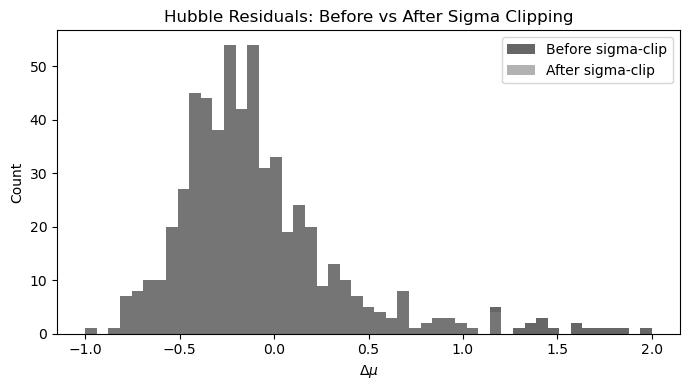

555 SNe after SFR <= 2.5 cut.
553 SNe after DN4000 >= 0.5 cut.
550 SNe after AGE >= 2 Gyr cut.

Final sample: 550 SNe


In [2]:
# Load the dataset
# Path is relative to the repo root where this notebook lives.
df = pd.read_csv('ZTF_DESI_ml_work/ZTF_DESI_data/ZTF_resid_cent_hostprop_no_x1_c.csv')
print(len(df), 'SNe before quality cuts.')

# --------------------------------------------------
# 1) Paper quality flags
# --------------------------------------------------
df = df[(df['lccoverage_flag'] == 1) & (df['fitquality_flag'] == 1)]
print(len(df), 'SNe after lccoverage + fitquality flags.')

# --------------------------------------------------
# 2) Derived feature: SDSS g - r host galaxy colour
# --------------------------------------------------
df['SDSS_g_minus_r'] = df['ABSMAG01_SDSS_G'] - df['ABSMAG01_SDSS_R']

# --------------------------------------------------
# 3) Global 3-sigma clip on Hubble residuals
# --------------------------------------------------
resid_before = df['residual_centered'].copy()
clip = sigma_clip(df['residual_centered'], sigma=3, maxiters=1)
df = df.loc[~clip.mask].reset_index(drop=True)
print(len(df), 'SNe after 3-sigma clip on residuals.')

# Visual check
fig, ax = plt.subplots(figsize=(7, 4))
bins = np.linspace(-1, 2, 50)
ax.hist(resid_before, bins=bins, label='Before sigma-clip', color='black', alpha=0.6)
ax.hist(df['residual_centered'], bins=bins, label='After sigma-clip', color='gray', alpha=0.6)
ax.set_xlabel(r'$\Delta\mu$')
ax.set_ylabel('Count')
ax.legend()
ax.set_title('Hubble Residuals: Before vs After Sigma Clipping')
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 4) Physical cuts on host-galaxy properties
# --------------------------------------------------
df = df.loc[df['SFR'] <= 2.5].reset_index(drop=True)
print(len(df), 'SNe after SFR <= 2.5 cut.')

df = df.loc[df['DN4000'] >= 0.5].reset_index(drop=True)
print(len(df), 'SNe after DN4000 >= 0.5 cut.')

df = df.loc[df['AGE'] >= 2].reset_index(drop=True)
print(len(df), 'SNe after AGE >= 2 Gyr cut.')

# Store measurement errors (must be done after all cuts so indices stay aligned)
yerr_all = df['sigma_mu_meas'].copy()

print('\nFinal sample:', len(df), 'SNe')

---
# Section: Feature Matrix & Train/Test Split

We define the 9 input features and the regression target, then create an **80/20 train/test split**
with `random_state=42` for reproducibility.

The per-SN measurement errors `sigma_mu_meas` are converted to **inverse-variance sample weights**
$w_i = 1/\sigma_i^2$ and passed to models that support weighted fitting. This down-weights SNe
with large photometric uncertainties.

In [3]:
feature_cols = [
    'LOGMSTAR',
    'c',
    'x1',
    'SFR',
    'VDISP',
    'DN4000',
    'SDSS_g_minus_r',
    'AGE',
    'redshift',
]

target_col = 'residual_centered'

X = df[feature_cols].copy()
y = df[target_col].copy()

# 80/20 split — keep measurement errors perfectly aligned with X and y
Xtr, Xte, ytr, yte, yerr_tr, yerr_te = train_test_split(
    X, y, yerr_all, test_size=0.2, random_state=42
)

# Inverse-variance sample weights for models that support them
w_tr = 1.0 / (yerr_tr.values ** 2)

print('Training set :', len(Xtr), 'samples')
print('Test set     :', len(Xte), 'samples')
print('Features     :', feature_cols)

Training set : 440 samples
Test set     : 110 samples
Features     : ['LOGMSTAR', 'c', 'x1', 'SFR', 'VDISP', 'DN4000', 'SDSS_g_minus_r', 'AGE', 'redshift']


---
# Section: Helper Functions

Three utility functions used throughout the notebook:

- **`evaluate_model`**: computes MAE, RMSE, and R² on the test set and appends the result to
  `all_metrics` for the final comparison section.
- **`plot_feature_importance`**: draws a horizontal bar chart of feature importances sorted
  descending.
- **`plot_pred_vs_actual`**: scatter plot of predicted vs actual $\Delta\mu$, useful for spotting
  systematic biases in each model.

In [4]:
# Accumulates one metrics dict per model; used in the Summary section.
all_metrics = []

# Storage for feature importance Series (one per model) for the final heatmap.
fi_store = {}

# Storage for train R² and CV R² — used in the Overfitting Check section.
all_train_r2 = {}
all_cv_r2    = {}


def evaluate_model(name, y_true, y_pred):
    """Compute and print MAE, RMSE, R2 for a fitted model on the test set."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f'  MAE  = {mae:.4f}')
    print(f'  RMSE = {rmse:.4f}')
    print(f'  R2   = {r2:.4f}')
    metrics = {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}
    all_metrics.append(metrics)
    return metrics


def plot_feature_importance(importances, feature_names, title, color='steelblue'):
    """Horizontal bar chart of feature importances, sorted descending."""
    fi = pd.Series(importances, index=feature_names).sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(7, 4))
    fi.plot(kind='barh', ax=ax, color=color, edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel('Importance')
    ax.axvline(0, color='black', linewidth=0.8)
    plt.tight_layout()
    plt.show()


def plot_pred_vs_actual(y_true, y_pred, name):
    """Scatter of predicted vs actual Hubble residuals with a 1:1 reference line."""
    yt = np.array(y_true)
    yp = np.array(y_pred)
    lo = min(yt.min(), yp.min()) - 0.05
    hi = max(yt.max(), yp.max()) + 0.05
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(yt, yp, alpha=0.4, s=20, color='steelblue')
    ax.plot([lo, hi], [lo, hi], 'k--', linewidth=1, label='Perfect prediction')
    ax.set_xlabel(r'Actual $\Delta\mu$')
    ax.set_ylabel(r'Predicted $\Delta\mu$')
    ax.set_title(f'{name}: Predicted vs Actual')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

---
# Section: Hyperparameter Tuning Strategy

Each model section below contains a **1-D hyperparameter sweep** before the final model fit.

### Method
- **`cross_val_predict` (cv=5)** on the **training set only** — each supernova gets a
  prediction from when it was held out, giving a fair out-of-sample estimate.
  The test set is never seen during this sweep.
- **NMAD** = $1.4826 \times \text{median}(|y_\text{pred} - y|)$ — a robust scatter
  statistic (equivalent to $\sigma$ for a Gaussian but insensitive to outliers).
  Preferred over RMSE for Hubble residuals where extreme outliers can dominate.
- **Outlier rate** = fraction of SNe with $|\text{error}| > 0.1$ mag.
- The hyperparameter that **minimises NMAD** is selected and used in the final model fit.

### Why not GridSearchCV or RandomizedSearchCV?
For a single key hyperparameter per model, a manual sweep is preferable because:
1. It produces an interpretable **plot** showing how performance varies continuously.
2. It makes the model's sensitivity to the hyperparameter immediately visible.
For multi-parameter searches (future work), `RandomizedSearchCV` or Bayesian optimisation
(e.g. `Optuna`) would be more efficient.

---
# Section: Random Forest Regressor

Random Forest is an ensemble of decision trees, each trained on a **bootstrap resample** of the
training data. At each split, only a random subset of features (`max_features='sqrt'`) is
considered, which decorrelates the trees and reduces variance.

**Feature importance** is the Mean Decrease in Impurity (MDI): the total reduction in MSE
attributed to each feature, averaged across all trees and all splits.

| Hyperparameter | Value | Rationale |
|---|---|---|
| `n_estimators` | 1000 | large forest for stable importance estimates |
| `min_samples_leaf` | 5 | prevents leaves overfitting to photometric noise |
| `max_features` | `sqrt` | standard decorrelation heuristic |
| `bootstrap` | True | standard bagging |

Best min_samples_leaf (RF) = 1  ->  CV NMAD = 0.1664


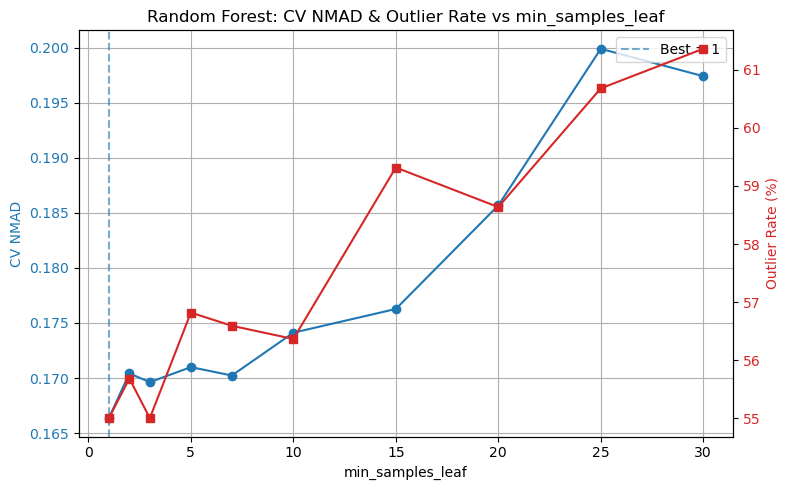

In [5]:
# -------------------------------------------------------
# Hyperparameter Tuning: Random Forest — min_samples_leaf
# -------------------------------------------------------
# min_samples_leaf is the most effective regularisation knob for RF on
# small datasets (~460 training samples). It sets the minimum number of
# samples that must sit in a leaf node.
#   - leaf=1 : trees can memorise individual noisy measurements
#   - leaf=20: trees average too broadly, model underfits
# n_estimators=200 is used here for speed; the final model uses 1000.

leaf_range_rf = np.array([1, 2, 3, 5, 7, 10, 15, 20, 25, 30])
nmad_rf_tune, outlier_rf_tune = [], []

for leaf in leaf_range_rf:
    rf_t = RandomForestRegressor(
        n_estimators=200, min_samples_leaf=leaf,
        max_features='sqrt', bootstrap=True, n_jobs=-1, random_state=42,
    )
    y_pred = cross_val_predict(rf_t, Xtr, ytr, cv=5)
    nmad_rf_tune.append(1.4826 * np.median(np.abs(y_pred - ytr)))
    outlier_rf_tune.append(100.0 * np.mean(np.abs(ytr - y_pred) > 0.1))

best_leaf_rf = int(leaf_range_rf[np.argmin(nmad_rf_tune)])
print(f'Best min_samples_leaf (RF) = {best_leaf_rf}  ->  CV NMAD = {min(nmad_rf_tune):.4f}')

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.set_xlabel('min_samples_leaf')
ax1.set_ylabel('CV NMAD', color='tab:blue')
ax1.plot(leaf_range_rf, nmad_rf_tune, 'o-', color='tab:blue')
ax1.axvline(best_leaf_rf, color='tab:blue', linestyle='--', alpha=0.6,
            label=f'Best = {best_leaf_rf}')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.legend(loc='upper right')
ax1.grid(True)
ax2 = ax1.twinx()
ax2.set_ylabel('Outlier Rate (%)', color='tab:red')
ax2.plot(leaf_range_rf, outlier_rf_tune, 's-', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')
plt.title('Random Forest: CV NMAD & Outlier Rate vs min_samples_leaf')
fig.tight_layout()
plt.show()

=== Random Forest Regressor ===
Using best min_samples_leaf = 1 (tuned above)

Test-set metrics:
  MAE  = 0.1444
  RMSE = 0.1934
  R2   = 0.6484
  Train R2 = 0.9601  (overfit gap = 0.3117)
  5-fold CV R2: 0.6940 +/- 0.0246

Feature Importances (MDI):
c                 0.500641
x1                0.142157
redshift          0.095155
SDSS_g_minus_r    0.054844
LOGMSTAR          0.048679
DN4000            0.041393
SFR               0.039727
VDISP             0.039356
AGE               0.038048


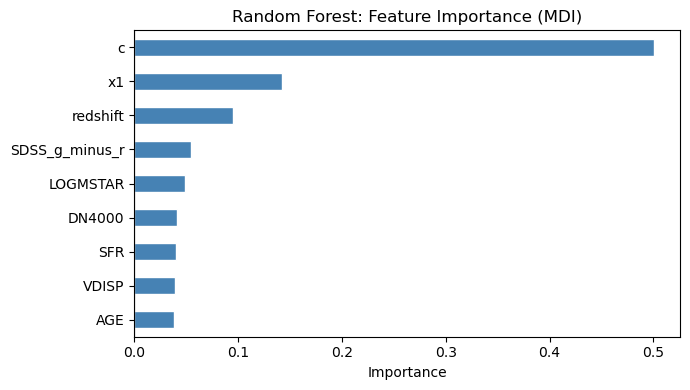

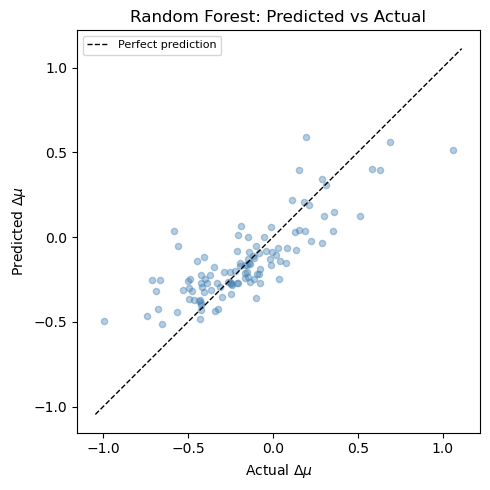

In [6]:
print('=== Random Forest Regressor ===')
print(f'Using best min_samples_leaf = {best_leaf_rf} (tuned above)\n')

rf = RandomForestRegressor(
    n_estimators=1000,
    max_depth=None,
    min_samples_leaf=best_leaf_rf,
    max_features='sqrt',
    bootstrap=True,
    n_jobs=-1,
    random_state=42,
)

rf.fit(Xtr, ytr, sample_weight=w_tr)
yhat_rf     = rf.predict(Xte)
train_r2_rf = r2_score(ytr, rf.predict(Xtr))
test_r2_rf  = r2_score(yte, yhat_rf)
all_train_r2['Random Forest'] = train_r2_rf

# --- Performance metrics ---
print('Test-set metrics:')
evaluate_model('Random Forest', yte, yhat_rf)
print(f'  Train R2 = {train_r2_rf:.4f}  (overfit gap = {train_r2_rf - test_r2_rf:.4f})')

cv_rf = cross_val_score(rf, X, y, cv=5, scoring='r2', n_jobs=-1)
print(f'  5-fold CV R2: {cv_rf.mean():.4f} +/- {cv_rf.std():.4f}')
all_cv_r2['Random Forest'] = cv_rf.mean()

# --- Feature importance (MDI) ---
fi_rf = pd.Series(rf.feature_importances_, index=feature_cols)
fi_store['Random Forest'] = fi_rf
print('\nFeature Importances (MDI):')
print(fi_rf.sort_values(ascending=False).to_string())
plot_feature_importance(
    rf.feature_importances_, feature_cols,
    'Random Forest: Feature Importance (MDI)', color='steelblue'
)

# --- Predicted vs actual ---
plot_pred_vs_actual(yte, yhat_rf, 'Random Forest')

---
# Section: Gradient Boosting Regressor

Gradient Boosting builds trees **sequentially**: each new tree fits the negative gradient of the
loss (i.e., the current residuals of the ensemble). A learning-rate shrinkage is applied to each
tree's contribution. Unlike Random Forest which reduces variance, boosting primarily reduces
**bias** at the cost of higher sensitivity to hyperparameters.

Feature importance is MDI-based (same definition as Random Forest).

| Hyperparameter | Value | Rationale |
|---|---|---|
| `n_estimators` | 500 | number of boosting stages |
| `learning_rate` | 0.05 | small shrinkage reduces overfitting |
| `max_depth` | 3 | shallow trees are standard for boosting |
| `subsample` | 0.8 | stochastic boosting: samples 80% per stage |

Best max_depth (GBR) = 1  ->  CV NMAD = 0.1613


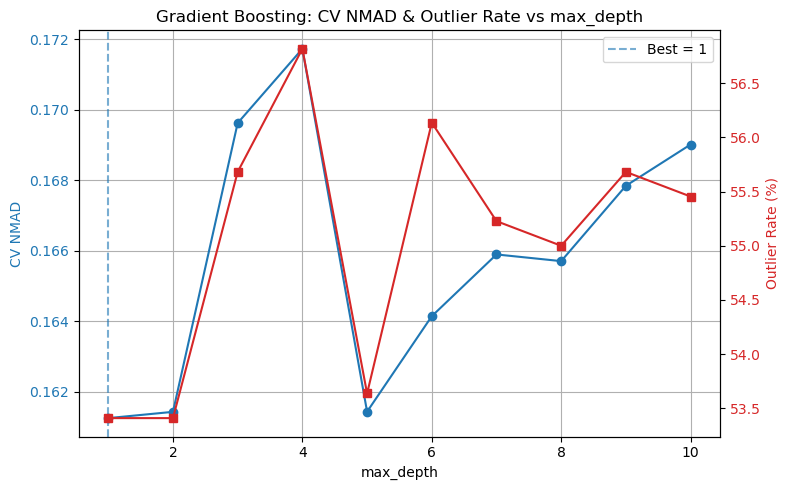

In [7]:
# -------------------------------------------------------
# Hyperparameter Tuning: Gradient Boosting — max_depth
# -------------------------------------------------------
# max_depth controls the complexity of each individual boosting stage.
# GBR is very sensitive to this because deep trees can fit the residuals
# of a nearly-converged ensemble, driving overfitting to noise.
# Standard best practice: keep depth shallow (1–5) with many rounds.
# n_estimators=300 used here for a balance of speed and stability.

depth_range_gbr = np.arange(1, 11)
nmad_gbr_tune, outlier_gbr_tune = [], []

for depth in depth_range_gbr:
    gbr_t = GradientBoostingRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=depth,
        min_samples_leaf=5, subsample=0.8, random_state=42,
    )
    y_pred = cross_val_predict(gbr_t, Xtr, ytr, cv=5)
    nmad_gbr_tune.append(1.4826 * np.median(np.abs(y_pred - ytr)))
    outlier_gbr_tune.append(100.0 * np.mean(np.abs(ytr - y_pred) > 0.1))

best_depth_gbr = int(depth_range_gbr[np.argmin(nmad_gbr_tune)])
print(f'Best max_depth (GBR) = {best_depth_gbr}  ->  CV NMAD = {min(nmad_gbr_tune):.4f}')

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.set_xlabel('max_depth')
ax1.set_ylabel('CV NMAD', color='tab:blue')
ax1.plot(depth_range_gbr, nmad_gbr_tune, 'o-', color='tab:blue')
ax1.axvline(best_depth_gbr, color='tab:blue', linestyle='--', alpha=0.6,
            label=f'Best = {best_depth_gbr}')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.legend(loc='upper right')
ax1.grid(True)
ax2 = ax1.twinx()
ax2.set_ylabel('Outlier Rate (%)', color='tab:red')
ax2.plot(depth_range_gbr, outlier_gbr_tune, 's-', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')
plt.title('Gradient Boosting: CV NMAD & Outlier Rate vs max_depth')
fig.tight_layout()
plt.show()

=== Gradient Boosting Regressor ===
Using best max_depth = 1 (tuned above)

Test-set metrics:
  MAE  = 0.1336
  RMSE = 0.1763
  R2   = 0.7078
  Train R2 = 0.8236  (overfit gap = 0.1158)
  5-fold CV R2: 0.7129 +/- 0.0362

Feature Importances (MDI):
c                 0.750564
x1                0.160004
redshift          0.028027
DN4000            0.019718
SDSS_g_minus_r    0.014612
LOGMSTAR          0.010546
SFR               0.006845
VDISP             0.006394
AGE               0.003290


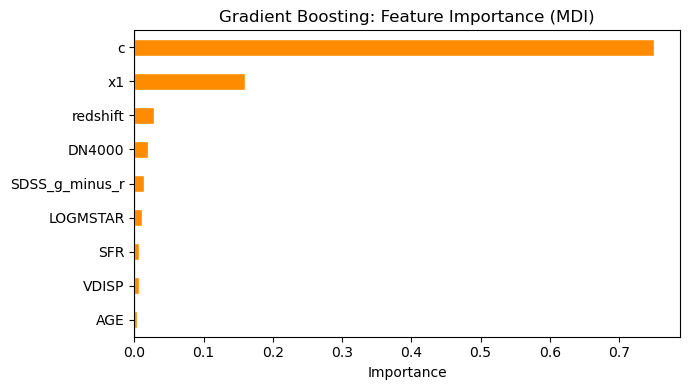

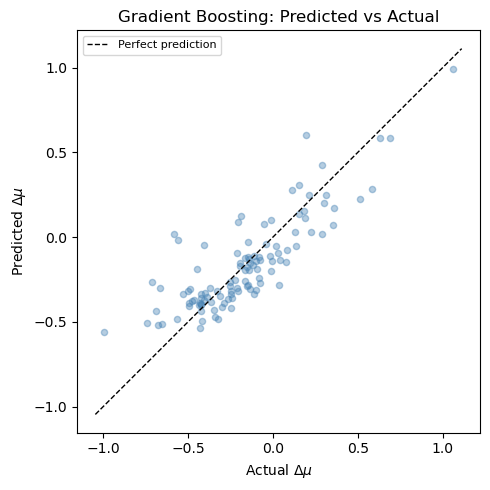

In [8]:
print('=== Gradient Boosting Regressor ===')
print(f'Using best max_depth = {best_depth_gbr} (tuned above)\n')

gbr = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=best_depth_gbr,
    min_samples_leaf=5,
    subsample=0.8,
    random_state=42,
)

gbr.fit(Xtr, ytr, sample_weight=w_tr)
yhat_gbr     = gbr.predict(Xte)
train_r2_gbr = r2_score(ytr, gbr.predict(Xtr))
test_r2_gbr  = r2_score(yte, yhat_gbr)
all_train_r2['Gradient Boosting'] = train_r2_gbr

# --- Performance metrics ---
print('Test-set metrics:')
evaluate_model('Gradient Boosting', yte, yhat_gbr)
print(f'  Train R2 = {train_r2_gbr:.4f}  (overfit gap = {train_r2_gbr - test_r2_gbr:.4f})')

cv_gbr = cross_val_score(gbr, X, y, cv=5, scoring='r2', n_jobs=-1)
print(f'  5-fold CV R2: {cv_gbr.mean():.4f} +/- {cv_gbr.std():.4f}')
all_cv_r2['Gradient Boosting'] = cv_gbr.mean()

# --- Feature importance (MDI) ---
fi_gbr = pd.Series(gbr.feature_importances_, index=feature_cols)
fi_store['Gradient Boosting'] = fi_gbr
print('\nFeature Importances (MDI):')
print(fi_gbr.sort_values(ascending=False).to_string())
plot_feature_importance(
    gbr.feature_importances_, feature_cols,
    'Gradient Boosting: Feature Importance (MDI)', color='darkorange'
)

# --- Predicted vs actual ---
plot_pred_vs_actual(yte, yhat_gbr, 'Gradient Boosting')

---
# Section: Extra Trees Regressor

Extra Trees (Extremely Randomized Trees) is similar to Random Forest but introduces additional
randomness: instead of finding the **optimal** split threshold, it picks the threshold
**uniformly at random** from the feature range. This further decorrelates the trees, often
reducing variance at the cost of a small bias increase.

Key difference from RF: Extra Trees uses the **full training set** (no bootstrap by default),
so variance reduction comes entirely from the random split thresholds rather than resampling.

Best min_samples_leaf (ET) = 1  ->  CV NMAD = 0.1640


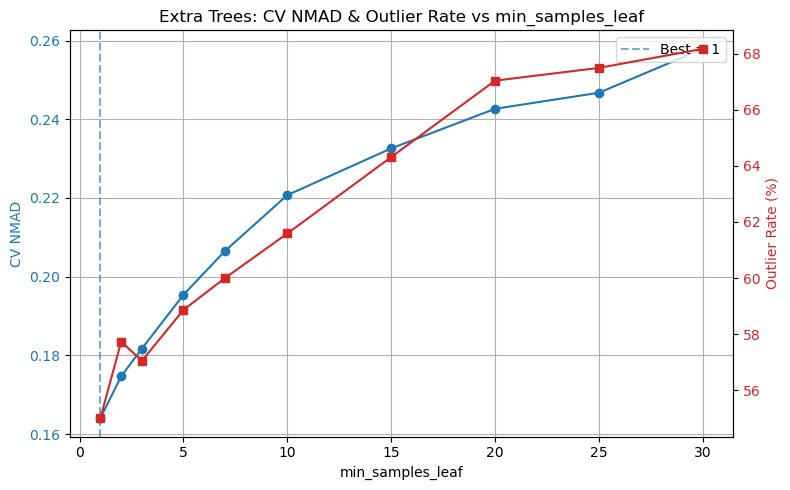

In [9]:
# -------------------------------------------------------
# Hyperparameter Tuning: Extra Trees — min_samples_leaf
# -------------------------------------------------------
# Same regularisation parameter as RF. Extra Trees are more aggressive
# splitters (random thresholds), so they tend to need a slightly larger
# min_samples_leaf to avoid overfitting noise on small datasets.
# n_estimators=200 for speed; final model uses 1000.

leaf_range_et = np.array([1, 2, 3, 5, 7, 10, 15, 20, 25, 30])
nmad_et_tune, outlier_et_tune = [], []

for leaf in leaf_range_et:
    et_t = ExtraTreesRegressor(
        n_estimators=200, min_samples_leaf=leaf,
        max_features='sqrt', bootstrap=False, n_jobs=-1, random_state=42,
    )
    y_pred = cross_val_predict(et_t, Xtr, ytr, cv=5)
    nmad_et_tune.append(1.4826 * np.median(np.abs(y_pred - ytr)))
    outlier_et_tune.append(100.0 * np.mean(np.abs(ytr - y_pred) > 0.1))

best_leaf_et = int(leaf_range_et[np.argmin(nmad_et_tune)])
print(f'Best min_samples_leaf (ET) = {best_leaf_et}  ->  CV NMAD = {min(nmad_et_tune):.4f}')

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.set_xlabel('min_samples_leaf')
ax1.set_ylabel('CV NMAD', color='tab:blue')
ax1.plot(leaf_range_et, nmad_et_tune, 'o-', color='tab:blue')
ax1.axvline(best_leaf_et, color='tab:blue', linestyle='--', alpha=0.6,
            label=f'Best = {best_leaf_et}')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.legend(loc='upper right')
ax1.grid(True)
ax2 = ax1.twinx()
ax2.set_ylabel('Outlier Rate (%)', color='tab:red')
ax2.plot(leaf_range_et, outlier_et_tune, 's-', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')
plt.title('Extra Trees: CV NMAD & Outlier Rate vs min_samples_leaf')
fig.tight_layout()
plt.show()

=== Extra Trees Regressor ===
Using best min_samples_leaf = 1 (tuned above)

Test-set metrics:
  MAE  = 0.1415
  RMSE = 0.1899
  R2   = 0.6610
  Train R2 = 1.0000  (overfit gap = 0.3390)
  5-fold CV R2: 0.6994 +/- 0.0268

Feature Importances (MDI):
c                 0.519767
x1                0.121310
redshift          0.073083
SDSS_g_minus_r    0.054876
LOGMSTAR          0.054203
SFR               0.046344
DN4000            0.044305
VDISP             0.043780
AGE               0.042332


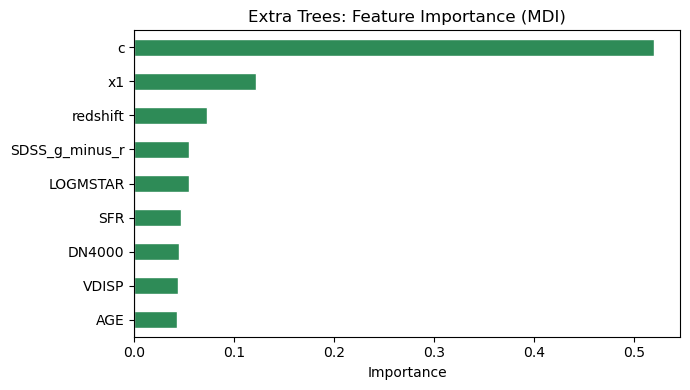

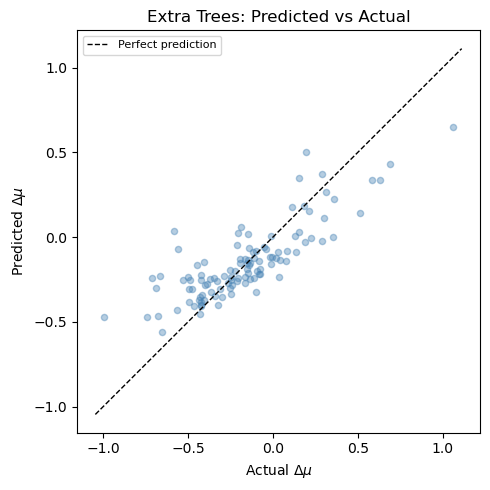

In [10]:
print('=== Extra Trees Regressor ===')
print(f'Using best min_samples_leaf = {best_leaf_et} (tuned above)\n')

et = ExtraTreesRegressor(
    n_estimators=1000,
    min_samples_leaf=best_leaf_et,
    max_features='sqrt',
    bootstrap=False,
    n_jobs=-1,
    random_state=42,
)

et.fit(Xtr, ytr, sample_weight=w_tr)
yhat_et     = et.predict(Xte)
train_r2_et = r2_score(ytr, et.predict(Xtr))
test_r2_et  = r2_score(yte, yhat_et)
all_train_r2['Extra Trees'] = train_r2_et

# --- Performance metrics ---
print('Test-set metrics:')
evaluate_model('Extra Trees', yte, yhat_et)
print(f'  Train R2 = {train_r2_et:.4f}  (overfit gap = {train_r2_et - test_r2_et:.4f})')

cv_et = cross_val_score(et, X, y, cv=5, scoring='r2', n_jobs=-1)
print(f'  5-fold CV R2: {cv_et.mean():.4f} +/- {cv_et.std():.4f}')
all_cv_r2['Extra Trees'] = cv_et.mean()

# --- Feature importance (MDI) ---
fi_et = pd.Series(et.feature_importances_, index=feature_cols)
fi_store['Extra Trees'] = fi_et
print('\nFeature Importances (MDI):')
print(fi_et.sort_values(ascending=False).to_string())
plot_feature_importance(
    et.feature_importances_, feature_cols,
    'Extra Trees: Feature Importance (MDI)', color='seagreen'
)

# --- Predicted vs actual ---
plot_pred_vs_actual(yte, yhat_et, 'Extra Trees')

---
# Section: Ridge Regression (Linear Baseline)

Ridge Regression is a regularized linear model with an **L2 penalty** on coefficient magnitudes:

$$\hat{\beta} = \arg\min_\beta \sum_i w_i (y_i - \beta^\top x_i)^2 + \alpha \|\beta\|_2^2$$

It assumes a *linear* relationship — a useful baseline to check whether the Hubble residuals
depart significantly from a linear dependence on host properties.

**Feature importance proxy:** after standardizing inputs, the magnitude of each coefficient
$|\beta_j|$ tells us how much a 1-SD change in feature $j$ shifts $\Delta\mu$. Inputs are
standardized inside a `Pipeline` so coefficients are on a comparable scale.

Best alpha (Ridge) = 17.78  ->  CV NMAD = 0.1477


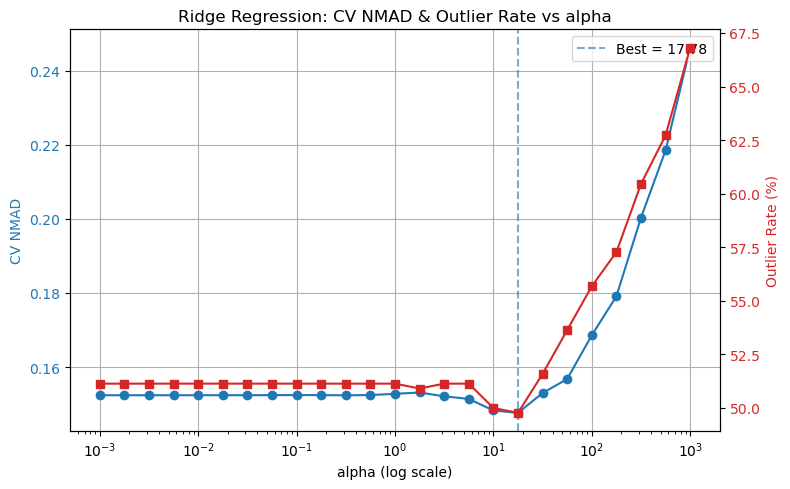

In [11]:
# -------------------------------------------------------
# Hyperparameter Tuning: Ridge — alpha (L2 strength)
# -------------------------------------------------------
# alpha controls how strongly coefficients are penalised toward zero.
#   - alpha -> 0  : approaches OLS; risk of variance amplification
#   - alpha -> inf: all coefficients crushed to zero (underfitting)
# The Pipeline refits StandardScaler on each training fold — no data leakage.
# Log-spaced grid: regularisation parameters typically span many decades.

alpha_range_ridge = np.logspace(-3, 3, 25)
nmad_ridge_tune, outlier_ridge_tune = [], []

for alpha in alpha_range_ridge:
    pipe_t = Pipeline([('scaler', StandardScaler()), ('ridge', Ridge(alpha=alpha))])
    y_pred = cross_val_predict(pipe_t, Xtr, ytr, cv=5)
    nmad_ridge_tune.append(1.4826 * np.median(np.abs(y_pred - ytr)))
    outlier_ridge_tune.append(100.0 * np.mean(np.abs(ytr - y_pred) > 0.1))

best_alpha_ridge = float(alpha_range_ridge[np.argmin(nmad_ridge_tune)])
print(f'Best alpha (Ridge) = {best_alpha_ridge:.4g}  ->  CV NMAD = {min(nmad_ridge_tune):.4f}')

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.set_xlabel('alpha (log scale)')
ax1.set_ylabel('CV NMAD', color='tab:blue')
ax1.semilogx(alpha_range_ridge, nmad_ridge_tune, 'o-', color='tab:blue')
ax1.axvline(best_alpha_ridge, color='tab:blue', linestyle='--', alpha=0.6,
            label=f'Best = {best_alpha_ridge:.4g}')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.legend(loc='upper right')
ax1.grid(True)
ax2 = ax1.twinx()
ax2.set_ylabel('Outlier Rate (%)', color='tab:red')
ax2.semilogx(alpha_range_ridge, outlier_ridge_tune, 's-', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')
plt.title('Ridge Regression: CV NMAD & Outlier Rate vs alpha')
fig.tight_layout()
plt.show()

=== Ridge Regression ===
Using best alpha = 17.78 (tuned above)

Test-set metrics:
  MAE  = 0.1312
  RMSE = 0.1773
  R2   = 0.7048
  Train R2 = 0.7615  (overfit gap = 0.0568)
  5-fold CV R2: 0.7414 +/- 0.0475

Signed standardized coefficients:
c                 0.275344
LOGMSTAR          0.011942
SFR               0.000508
VDISP            -0.008773
AGE              -0.010033
SDSS_g_minus_r   -0.019931
DN4000           -0.029547
redshift         -0.042167
x1               -0.137552


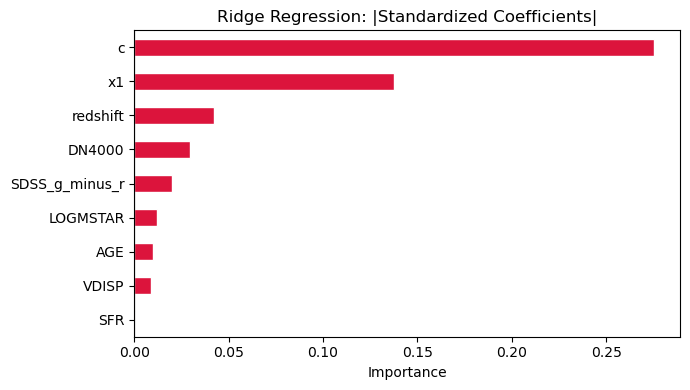

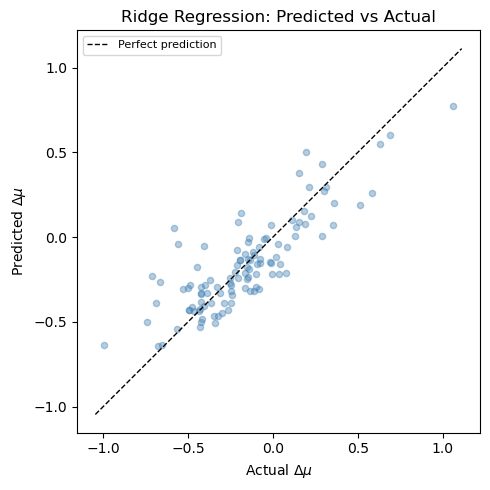

In [12]:
print('=== Ridge Regression ===')
print(f'Using best alpha = {best_alpha_ridge:.4g} (tuned above)\n')

scaler_ridge = StandardScaler()
Xtr_s = scaler_ridge.fit_transform(Xtr)
Xte_s = scaler_ridge.transform(Xte)

ridge = Ridge(alpha=best_alpha_ridge)
ridge.fit(Xtr_s, ytr, sample_weight=w_tr)
yhat_ridge     = ridge.predict(Xte_s)
train_r2_ridge = r2_score(ytr, ridge.predict(Xtr_s))
test_r2_ridge  = r2_score(yte, yhat_ridge)
all_train_r2['Ridge Regression'] = train_r2_ridge

# --- Performance metrics ---
print('Test-set metrics:')
evaluate_model('Ridge Regression', yte, yhat_ridge)
print(f'  Train R2 = {train_r2_ridge:.4f}  (overfit gap = {train_r2_ridge - test_r2_ridge:.4f})')

ridge_pipe = Pipeline([('scaler', StandardScaler()), ('ridge', Ridge(alpha=best_alpha_ridge))])
cv_ridge = cross_val_score(ridge_pipe, X, y, cv=5, scoring='r2', n_jobs=-1)
print(f'  5-fold CV R2: {cv_ridge.mean():.4f} +/- {cv_ridge.std():.4f}')
all_cv_r2['Ridge Regression'] = cv_ridge.mean()

# --- Feature importance: |standardized coefficients| ---
abs_coef_ridge = np.abs(ridge.coef_)
fi_ridge = pd.Series(abs_coef_ridge, index=feature_cols)
fi_store['Ridge |coef|'] = fi_ridge
print('\nSigned standardized coefficients:')
print(pd.Series(ridge.coef_, index=feature_cols).sort_values(ascending=False).to_string())
plot_feature_importance(
    abs_coef_ridge, feature_cols,
    'Ridge Regression: |Standardized Coefficients|', color='crimson'
)

# --- Predicted vs actual ---
plot_pred_vs_actual(yte, yhat_ridge, 'Ridge Regression')

---
# Section: ElasticNet Regression

ElasticNet combines **L1 (Lasso)** and **L2 (Ridge)** regularization:

$$\hat{\beta} = \arg\min_\beta \sum_i w_i (y_i - \beta^\top x_i)^2
  + \alpha \bigl[ \rho \|\beta\|_1 + \tfrac{1-\rho}{2} \|\beta\|_2^2 \bigr]$$

where `l1_ratio` $= \rho$ controls the L1/L2 mix. The L1 component can drive some coefficients
to **exactly zero**, performing automatic feature selection. This is useful for identifying a
sparse, interpretable set of predictors.

We use `l1_ratio=0.5` (balanced L1/L2) with `alpha=0.05`.

Best alpha (ElasticNet) = 0.01778  ->  CV NMAD = 0.1429


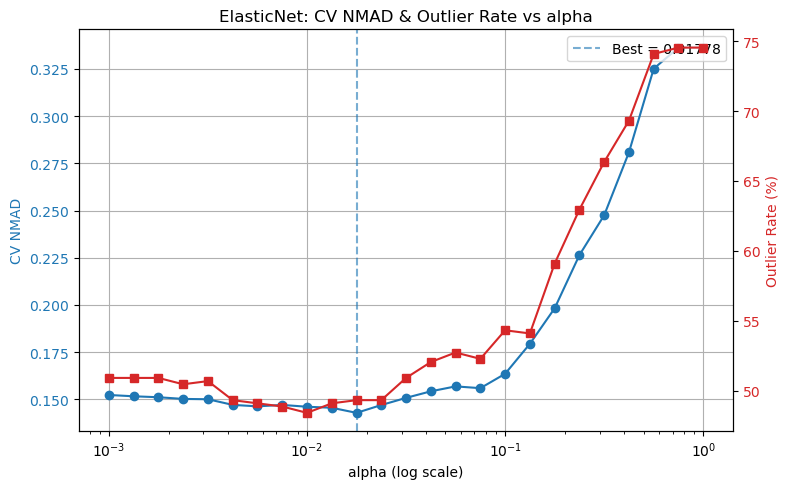

In [13]:
# -------------------------------------------------------
# Hyperparameter Tuning: ElasticNet — alpha
# -------------------------------------------------------
# alpha sets the overall regularisation strength (both L1 and L2 terms).
# With l1_ratio=0.5 (equal L1/L2 mix), a small alpha keeps all features
# active while a large alpha zeros out the weak ones.
# Pipeline with StandardScaler refitted inside each CV fold.

alpha_range_enet = np.logspace(-3, 0, 25)
nmad_enet_tune, outlier_enet_tune = [], []

for alpha in alpha_range_enet:
    pipe_t = Pipeline([
        ('scaler', StandardScaler()),
        ('enet', ElasticNet(alpha=alpha, l1_ratio=0.5, max_iter=5000)),
    ])
    y_pred = cross_val_predict(pipe_t, Xtr, ytr, cv=5)
    nmad_enet_tune.append(1.4826 * np.median(np.abs(y_pred - ytr)))
    outlier_enet_tune.append(100.0 * np.mean(np.abs(ytr - y_pred) > 0.1))

best_alpha_enet = float(alpha_range_enet[np.argmin(nmad_enet_tune)])
print(f'Best alpha (ElasticNet) = {best_alpha_enet:.4g}  ->  CV NMAD = {min(nmad_enet_tune):.4f}')

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.set_xlabel('alpha (log scale)')
ax1.set_ylabel('CV NMAD', color='tab:blue')
ax1.semilogx(alpha_range_enet, nmad_enet_tune, 'o-', color='tab:blue')
ax1.axvline(best_alpha_enet, color='tab:blue', linestyle='--', alpha=0.6,
            label=f'Best = {best_alpha_enet:.4g}')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.legend(loc='upper right')
ax1.grid(True)
ax2 = ax1.twinx()
ax2.set_ylabel('Outlier Rate (%)', color='tab:red')
ax2.semilogx(alpha_range_enet, outlier_enet_tune, 's-', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')
plt.title('ElasticNet: CV NMAD & Outlier Rate vs alpha')
fig.tight_layout()
plt.show()

=== ElasticNet Regression ===
Using best alpha = 0.01778 (tuned above)

Test-set metrics:
  MAE  = 0.1350
  RMSE = 0.1806
  R2   = 0.6935
  Train R2 = 0.7567  (overfit gap = 0.0632)
  5-fold CV R2: 0.7411 +/- 0.0480

Signed standardized coefficients (L1 may zero-out features):
c                 0.265358
LOGMSTAR         -0.000000
SFR               0.000000
VDISP            -0.000000
SDSS_g_minus_r   -0.000000
AGE              -0.000029
DN4000           -0.024673
redshift         -0.033049
x1               -0.116701
Features zeroed by L1 regularization: 4 / 9


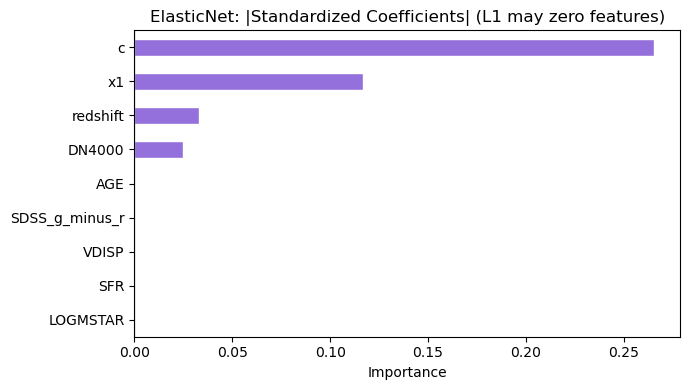

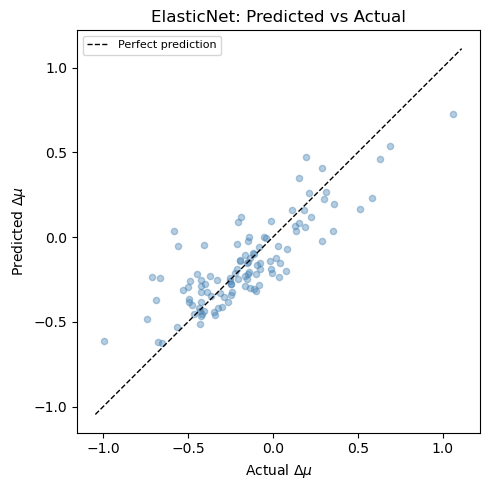

In [14]:
print('=== ElasticNet Regression ===')
print(f'Using best alpha = {best_alpha_enet:.4g} (tuned above)\n')

scaler_enet = StandardScaler()
Xtr_se = scaler_enet.fit_transform(Xtr)
Xte_se = scaler_enet.transform(Xte)

enet = ElasticNet(alpha=best_alpha_enet, l1_ratio=0.5, max_iter=5000)
enet.fit(Xtr_se, ytr, sample_weight=w_tr)
yhat_enet     = enet.predict(Xte_se)
train_r2_enet = r2_score(ytr, enet.predict(Xtr_se))
test_r2_enet  = r2_score(yte, yhat_enet)
all_train_r2['ElasticNet'] = train_r2_enet

# --- Performance metrics ---
print('Test-set metrics:')
evaluate_model('ElasticNet', yte, yhat_enet)
print(f'  Train R2 = {train_r2_enet:.4f}  (overfit gap = {train_r2_enet - test_r2_enet:.4f})')

enet_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('enet', ElasticNet(alpha=best_alpha_enet, l1_ratio=0.5, max_iter=5000)),
])
cv_enet = cross_val_score(enet_pipe, X, y, cv=5, scoring='r2', n_jobs=-1)
print(f'  5-fold CV R2: {cv_enet.mean():.4f} +/- {cv_enet.std():.4f}')
all_cv_r2['ElasticNet'] = cv_enet.mean()

# --- Feature importance: |standardized coefficients| ---
abs_coef_enet = np.abs(enet.coef_)
fi_enet = pd.Series(abs_coef_enet, index=feature_cols)
fi_store['ElasticNet |coef|'] = fi_enet
print('\nSigned standardized coefficients (L1 may zero-out features):')
print(pd.Series(enet.coef_, index=feature_cols).sort_values(ascending=False).to_string())
n_zero = np.sum(enet.coef_ == 0)
print(f'Features zeroed by L1 regularization: {n_zero} / {len(feature_cols)}')
plot_feature_importance(
    abs_coef_enet, feature_cols,
    'ElasticNet: |Standardized Coefficients| (L1 may zero features)', color='mediumpurple'
)

# --- Predicted vs actual ---
plot_pred_vs_actual(yte, yhat_enet, 'ElasticNet')

---
# Section: Support Vector Regression (SVR)

SVR finds a function that fits all training points within an $\epsilon$-insensitive tube while
being as flat as possible. With a **Radial Basis Function (RBF) kernel**, SVR implicitly maps
inputs into a high-dimensional feature space and can model non-linear relationships.

SVR has **no built-in feature importance**, so we use **permutation importance**: we randomly
shuffle one feature at a time on the test set and measure the drop in R². A large drop means
the model relies heavily on that feature.

**Implementation note:** SVR requires feature standardization (inputs on comparable scales).

Best C (SVR) = 0.2683  ->  CV NMAD = 0.1606


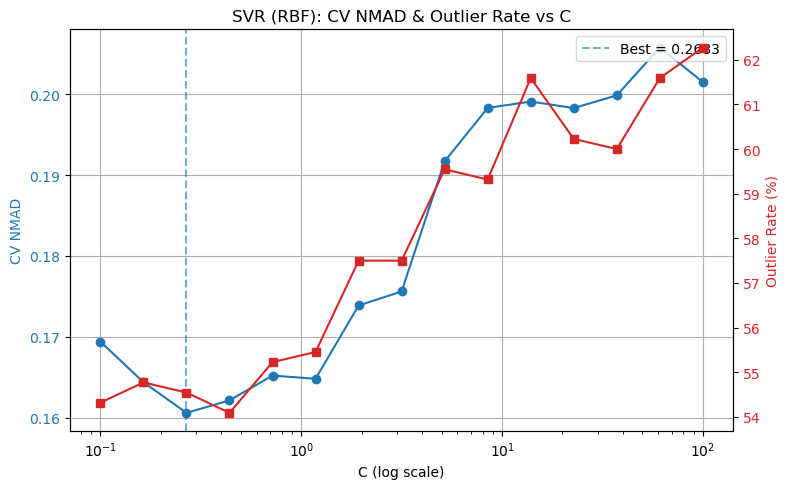

In [15]:
# -------------------------------------------------------
# Hyperparameter Tuning: SVR — C (soft-margin penalty)
# -------------------------------------------------------
# C controls how tightly the model fits training points.
#   - Small C: wider epsilon-tube, more regularisation, smoother fit
#   - Large C: allows more support vectors outside the tube, risks overfitting
# Pipeline refits StandardScaler inside each CV fold to prevent data leakage.

C_range_svr = np.logspace(-1, 2, 15)
nmad_svr_tune, outlier_svr_tune = [], []

for C in C_range_svr:
    pipe_t = Pipeline([
        ('scaler', StandardScaler()),
        ('svr', SVR(kernel='rbf', C=C, epsilon=0.1, gamma='scale')),
    ])
    y_pred = cross_val_predict(pipe_t, Xtr, ytr, cv=5)
    nmad_svr_tune.append(1.4826 * np.median(np.abs(y_pred - ytr)))
    outlier_svr_tune.append(100.0 * np.mean(np.abs(ytr - y_pred) > 0.1))

best_C_svr = float(C_range_svr[np.argmin(nmad_svr_tune)])
print(f'Best C (SVR) = {best_C_svr:.4g}  ->  CV NMAD = {min(nmad_svr_tune):.4f}')

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.set_xlabel('C (log scale)')
ax1.set_ylabel('CV NMAD', color='tab:blue')
ax1.semilogx(C_range_svr, nmad_svr_tune, 'o-', color='tab:blue')
ax1.axvline(best_C_svr, color='tab:blue', linestyle='--', alpha=0.6,
            label=f'Best = {best_C_svr:.4g}')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.legend(loc='upper right')
ax1.grid(True)
ax2 = ax1.twinx()
ax2.set_ylabel('Outlier Rate (%)', color='tab:red')
ax2.semilogx(C_range_svr, outlier_svr_tune, 's-', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')
plt.title('SVR (RBF): CV NMAD & Outlier Rate vs C')
fig.tight_layout()
plt.show()

=== Support Vector Regression (SVR, RBF kernel) ===
Using best C = 0.2683 (tuned above)

Test-set metrics:
  MAE  = 0.1781
  RMSE = 0.2403
  R2   = 0.4574
  Train R2 = 0.9345  (overfit gap = 0.4772)
  5-fold CV R2: 0.6713 +/- 0.0196

Permutation Importances (mean decrease in R2):
c                 1.078882
x1                0.733590
AGE               0.107448
DN4000            0.081052
SDSS_g_minus_r    0.069262
LOGMSTAR          0.067313
redshift          0.063122
SFR               0.059650
VDISP             0.048067


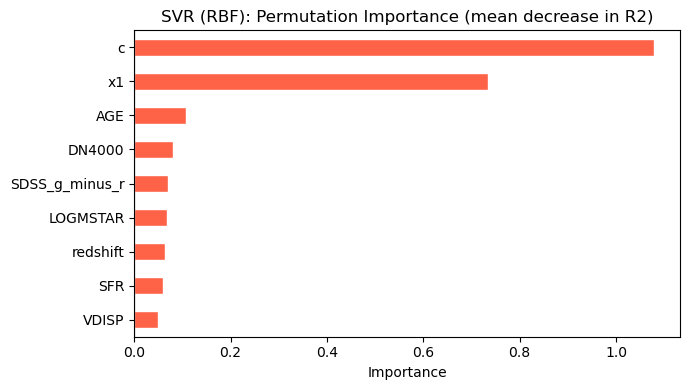

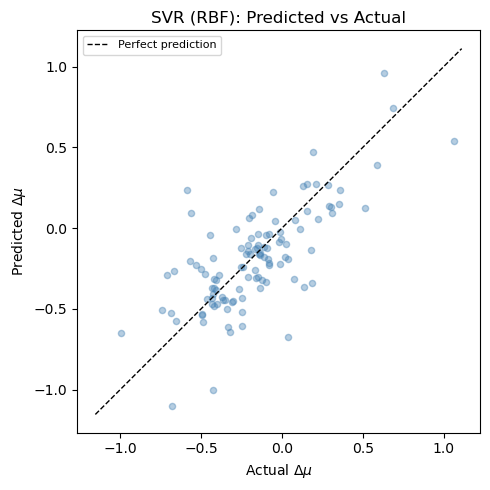

In [16]:
print('=== Support Vector Regression (SVR, RBF kernel) ===')
print(f'Using best C = {best_C_svr:.4g} (tuned above)\n')

scaler_svr = StandardScaler()
Xtr_sv = scaler_svr.fit_transform(Xtr)
Xte_sv = scaler_svr.transform(Xte)

svr = SVR(kernel='rbf', C=best_C_svr, epsilon=0.1, gamma='scale')
svr.fit(Xtr_sv, ytr, sample_weight=w_tr)
yhat_svr     = svr.predict(Xte_sv)
train_r2_svr = r2_score(ytr, svr.predict(Xtr_sv))
test_r2_svr  = r2_score(yte, yhat_svr)
all_train_r2['SVR (RBF)'] = train_r2_svr

# --- Performance metrics ---
print('Test-set metrics:')
evaluate_model('SVR (RBF)', yte, yhat_svr)
print(f'  Train R2 = {train_r2_svr:.4f}  (overfit gap = {train_r2_svr - test_r2_svr:.4f})')

svr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR(kernel='rbf', C=best_C_svr, epsilon=0.1, gamma='scale')),
])
cv_svr = cross_val_score(svr_pipe, X, y, cv=5, scoring='r2', n_jobs=-1)
print(f'  5-fold CV R2: {cv_svr.mean():.4f} +/- {cv_svr.std():.4f}')
all_cv_r2['SVR (RBF)'] = cv_svr.mean()

# --- Permutation importance on scaled test set ---
result_svr = permutation_importance(
    svr, Xte_sv, yte, n_repeats=30, random_state=42, scoring='r2'
)
fi_svr = pd.Series(result_svr.importances_mean, index=feature_cols)
fi_store['SVR perm.'] = fi_svr
print('\nPermutation Importances (mean decrease in R2):')
print(fi_svr.sort_values(ascending=False).to_string())
plot_feature_importance(
    result_svr.importances_mean, feature_cols,
    'SVR (RBF): Permutation Importance (mean decrease in R2)', color='tomato'
)

# --- Predicted vs actual ---
plot_pred_vs_actual(yte, yhat_svr, 'SVR (RBF)')

---
# Section: k-Nearest Neighbors Regressor

k-NN predicts the target for a new point as the **distance-weighted average** of its $k$ nearest
neighbours in feature space. It is a **non-parametric, instance-based** method with no
explicit training phase — all computation happens at prediction time.

Properties relevant to this dataset:
- Sensitive to **feature scaling** → inputs are standardized
- Can capture **local non-linear structure** in host properties
- No built-in feature importance → **permutation importance** is used
- Does **not** support `sample_weight` in `fit()`

Best k (k-NN) = 7  ->  CV NMAD = 0.1921


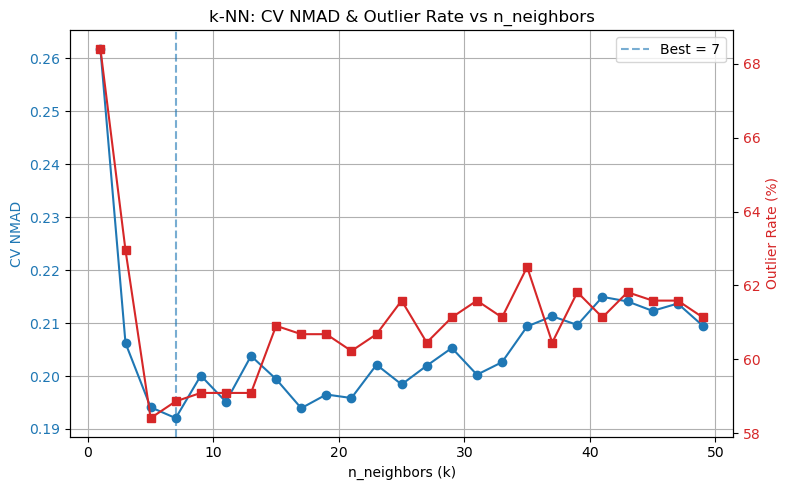

In [17]:
# -------------------------------------------------------
# Hyperparameter Tuning: k-NN — n_neighbors (k)
# -------------------------------------------------------
# k is the most important k-NN hyperparameter.
#   - k=1  : prediction = nearest neighbour only; memorises training noise
#   - k=50 : averages over many distant neighbours; underfits local structure
# Typical sweet spot for ~460 training samples: k in [5, 25].
# Pipeline refits StandardScaler inside each fold.

k_range_knn = np.arange(1, 51, 2)   # [1, 3, 5, ..., 49]
nmad_knn_tune, outlier_knn_tune = [], []

for k in k_range_knn:
    pipe_t = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsRegressor(n_neighbors=k, weights='distance', n_jobs=-1)),
    ])
    y_pred = cross_val_predict(pipe_t, Xtr, ytr, cv=5)
    nmad_knn_tune.append(1.4826 * np.median(np.abs(y_pred - ytr)))
    outlier_knn_tune.append(100.0 * np.mean(np.abs(ytr - y_pred) > 0.1))

best_k_knn = int(k_range_knn[np.argmin(nmad_knn_tune)])
print(f'Best k (k-NN) = {best_k_knn}  ->  CV NMAD = {min(nmad_knn_tune):.4f}')

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.set_xlabel('n_neighbors (k)')
ax1.set_ylabel('CV NMAD', color='tab:blue')
ax1.plot(k_range_knn, nmad_knn_tune, 'o-', color='tab:blue')
ax1.axvline(best_k_knn, color='tab:blue', linestyle='--', alpha=0.6,
            label=f'Best = {best_k_knn}')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.legend(loc='upper right')
ax1.grid(True)
ax2 = ax1.twinx()
ax2.set_ylabel('Outlier Rate (%)', color='tab:red')
ax2.plot(k_range_knn, outlier_knn_tune, 's-', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')
plt.title('k-NN: CV NMAD & Outlier Rate vs n_neighbors')
fig.tight_layout()
plt.show()

=== k-Nearest Neighbors Regressor (k=7) ===
Using best k = 7 (tuned above)

Test-set metrics:
  MAE  = 0.1760
  RMSE = 0.2272
  R2   = 0.5149
  Train R2 = 1.0000  (overfit gap = 0.4851)
  5-fold CV R2: 0.5976 +/- 0.0390

Permutation Importances (mean decrease in R2):
c                 0.607025
x1                0.258042
SDSS_g_minus_r    0.019987
LOGMSTAR          0.010740
redshift          0.008646
SFR               0.003697
DN4000           -0.012293
AGE              -0.015489
VDISP            -0.050177


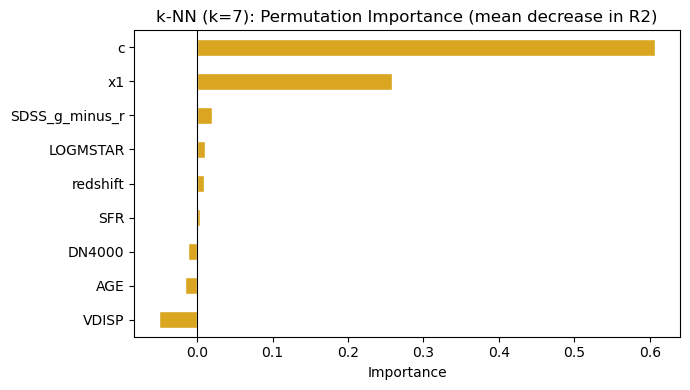

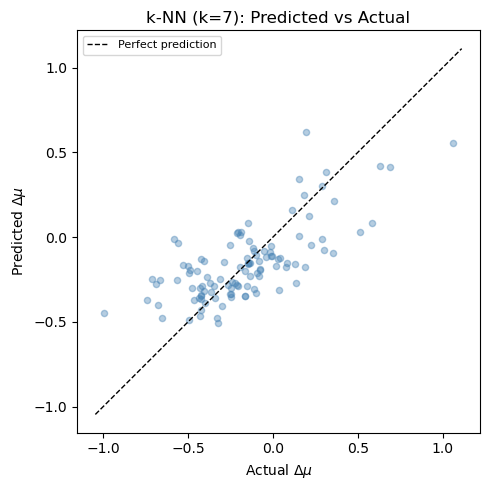

In [18]:
print(f'=== k-Nearest Neighbors Regressor (k={best_k_knn}) ===')
print(f'Using best k = {best_k_knn} (tuned above)\n')

knn_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsRegressor(n_neighbors=best_k_knn, weights='distance', n_jobs=-1)),
])

knn_pipe.fit(Xtr, ytr)   # KNeighborsRegressor does not support sample_weight
yhat_knn     = knn_pipe.predict(Xte)
train_r2_knn = r2_score(ytr, knn_pipe.predict(Xtr))
test_r2_knn  = r2_score(yte, yhat_knn)
all_train_r2['k-NN'] = train_r2_knn

# --- Performance metrics ---
print('Test-set metrics:')
evaluate_model('k-NN', yte, yhat_knn)
print(f'  Train R2 = {train_r2_knn:.4f}  (overfit gap = {train_r2_knn - test_r2_knn:.4f})')

cv_knn = cross_val_score(knn_pipe, X, y, cv=5, scoring='r2', n_jobs=-1)
print(f'  5-fold CV R2: {cv_knn.mean():.4f} +/- {cv_knn.std():.4f}')
all_cv_r2['k-NN'] = cv_knn.mean()

# --- Permutation importance ---
result_knn = permutation_importance(
    knn_pipe, Xte, yte, n_repeats=30, random_state=42, scoring='r2'
)
fi_knn = pd.Series(result_knn.importances_mean, index=feature_cols)
fi_store['k-NN perm.'] = fi_knn
print('\nPermutation Importances (mean decrease in R2):')
print(fi_knn.sort_values(ascending=False).to_string())
plot_feature_importance(
    result_knn.importances_mean, feature_cols,
    f'k-NN (k={best_k_knn}): Permutation Importance (mean decrease in R2)', color='goldenrod'
)

# --- Predicted vs actual ---
plot_pred_vs_actual(yte, yhat_knn, f'k-NN (k={best_k_knn})')

---
# Section: MLP Neural Network Regressor

A Multi-Layer Perceptron (MLP) is a feedforward neural network with non-linear activation
functions that can model arbitrarily complex relationships. With only ~460 training samples and
9 features, **overfitting is a real risk**, so we use:

- A modest **2-layer architecture**: 64 → 32 neurons with ReLU activation
- **L2 weight regularization** (`alpha=0.01`)
- **Early stopping**: training halts when the held-out validation loss stops improving

Feature importance is estimated via **permutation importance**.

**Note:** `MLPRegressor.fit()` does not support `sample_weight`.

Best alpha (MLP) = 1  ->  CV NMAD = 0.1552


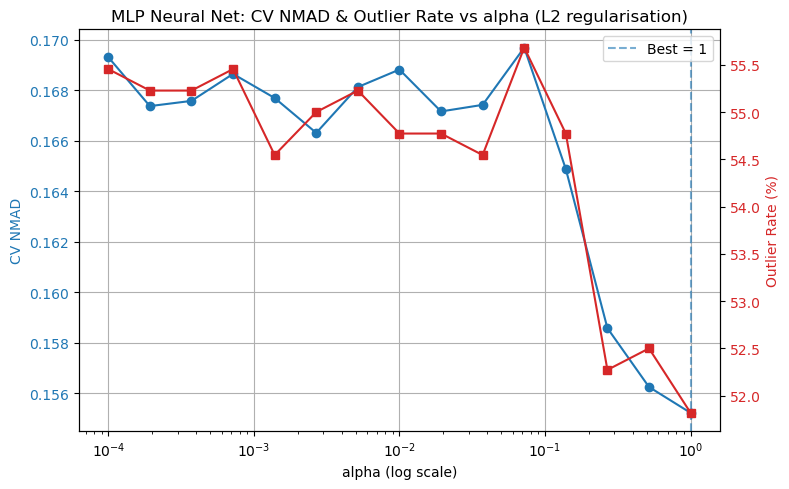

In [19]:
# -------------------------------------------------------
# Hyperparameter Tuning: MLP — alpha (L2 weight regularisation)
# -------------------------------------------------------
# alpha is the L2 weight decay coefficient.  With only ~460 training samples
# and 9 features, the MLP is highly prone to overfitting; alpha is the
# primary lever to prevent this.
#   - alpha too small: weights grow large, network memorises training data
#   - alpha too large: weights crushed to ~0, network underfits
# Note: early_stopping is disabled here so that cross_val_predict can manage
# the CV splits cleanly; max_iter=500 to keep the sweep fast.

alpha_range_mlp = np.logspace(-4, 0, 15)
nmad_mlp_tune, outlier_mlp_tune = [], []

for alpha in alpha_range_mlp:
    pipe_t = Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPRegressor(
            hidden_layer_sizes=(64, 32), activation='relu',
            alpha=alpha, learning_rate_init=1e-3,
            max_iter=500, early_stopping=False, random_state=42,
        )),
    ])
    y_pred = cross_val_predict(pipe_t, Xtr, ytr, cv=5)
    nmad_mlp_tune.append(1.4826 * np.median(np.abs(y_pred - ytr)))
    outlier_mlp_tune.append(100.0 * np.mean(np.abs(ytr - y_pred) > 0.1))

best_alpha_mlp = float(alpha_range_mlp[np.argmin(nmad_mlp_tune)])
print(f'Best alpha (MLP) = {best_alpha_mlp:.4g}  ->  CV NMAD = {min(nmad_mlp_tune):.4f}')

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.set_xlabel('alpha (log scale)')
ax1.set_ylabel('CV NMAD', color='tab:blue')
ax1.semilogx(alpha_range_mlp, nmad_mlp_tune, 'o-', color='tab:blue')
ax1.axvline(best_alpha_mlp, color='tab:blue', linestyle='--', alpha=0.6,
            label=f'Best = {best_alpha_mlp:.4g}')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.legend(loc='upper right')
ax1.grid(True)
ax2 = ax1.twinx()
ax2.set_ylabel('Outlier Rate (%)', color='tab:red')
ax2.semilogx(alpha_range_mlp, outlier_mlp_tune, 's-', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')
plt.title('MLP Neural Net: CV NMAD & Outlier Rate vs alpha (L2 regularisation)')
fig.tight_layout()
plt.show()

=== MLP Neural Network Regressor ===
Using best alpha = 1 (tuned above)

Test-set metrics:
  MAE  = 0.1271
  RMSE = 0.1753
  R2   = 0.7114
  Train R2 = 0.8141  (overfit gap = 0.1027)
  5-fold CV R2: 0.7433 +/- 0.0435

Permutation Importances (mean decrease in R2):
c                 0.972790
x1                0.488234
DN4000            0.042314
redshift          0.024984
SDSS_g_minus_r    0.015108
LOGMSTAR          0.015099
AGE               0.003614
SFR              -0.000276
VDISP            -0.000667


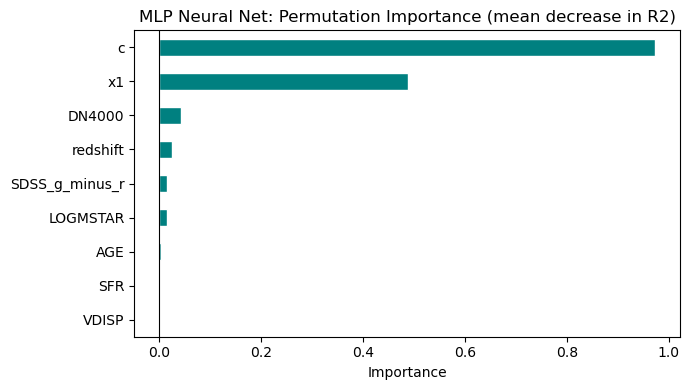

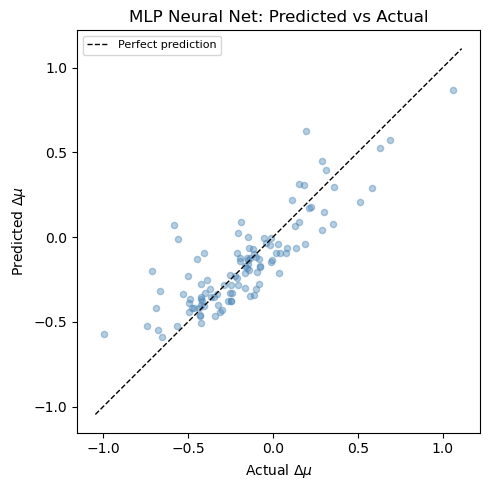

In [20]:
print('=== MLP Neural Network Regressor ===')
print(f'Using best alpha = {best_alpha_mlp:.4g} (tuned above)\n')

mlp_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        solver='adam',
        alpha=best_alpha_mlp,
        learning_rate_init=1e-3,
        max_iter=2000,
        early_stopping=True,
        n_iter_no_change=30,
        random_state=42,
    )),
])

mlp_pipe.fit(Xtr, ytr)   # MLPRegressor does not support sample_weight
yhat_mlp     = mlp_pipe.predict(Xte)
train_r2_mlp = r2_score(ytr, mlp_pipe.predict(Xtr))
test_r2_mlp  = r2_score(yte, yhat_mlp)
all_train_r2['MLP Neural Net'] = train_r2_mlp

# --- Performance metrics ---
print('Test-set metrics:')
evaluate_model('MLP Neural Net', yte, yhat_mlp)
print(f'  Train R2 = {train_r2_mlp:.4f}  (overfit gap = {train_r2_mlp - test_r2_mlp:.4f})')

cv_mlp = cross_val_score(mlp_pipe, X, y, cv=5, scoring='r2', n_jobs=-1)
print(f'  5-fold CV R2: {cv_mlp.mean():.4f} +/- {cv_mlp.std():.4f}')
all_cv_r2['MLP Neural Net'] = cv_mlp.mean()

# --- Permutation importance ---
result_mlp = permutation_importance(
    mlp_pipe, Xte, yte, n_repeats=30, random_state=42, scoring='r2'
)
fi_mlp = pd.Series(result_mlp.importances_mean, index=feature_cols)
fi_store['MLP Neural Net'] = fi_mlp
print('\nPermutation Importances (mean decrease in R2):')
print(fi_mlp.sort_values(ascending=False).to_string())
plot_feature_importance(
    result_mlp.importances_mean, feature_cols,
    'MLP Neural Net: Permutation Importance (mean decrease in R2)', color='teal'
)

# --- Predicted vs actual ---
plot_pred_vs_actual(yte, yhat_mlp, 'MLP Neural Net')

---
# Section: Overfitting Check

A model that scores well on training data but poorly on held-out data has **memorised** the
training set rather than learnt the underlying relationship. This is a serious risk here
because we have only ~460 training samples and 9 features — a relatively high feature-to-sample
ratio for non-linear models.

## Two complementary diagnostics

### 1. Train vs CV vs Test R² (bar chart)
For each model, we compare three R² values:

| Score | What it measures |
|---|---|
| **Train R²** | How well the model fits the data it was trained on |
| **5-fold CV R²** | Out-of-sample performance estimated during training |
| **Test R²** | Final held-out performance (never seen during training or tuning) |

**Interpretation:** If Train R² >> CV R² ≈ Test R², the model is overfitting.
If all three are low, the model is underfitting (high bias).
If Train R² ≈ CV R² ≈ Test R², the model generalises well.

### 2. Learning Curves (train vs CV R² vs training set size)
A learning curve plots how train and CV scores change as the training set grows.
- **Persistent gap** between train and CV curves → high variance (overfitting)
- **Convergence** of the two curves at low values → high bias (underfitting)
- **Convergence** at high values → well-fitted model

Learning curves are shown for the three tree-based models (RF, GBR, Extra Trees) which
are most likely to overfit on this dataset size.

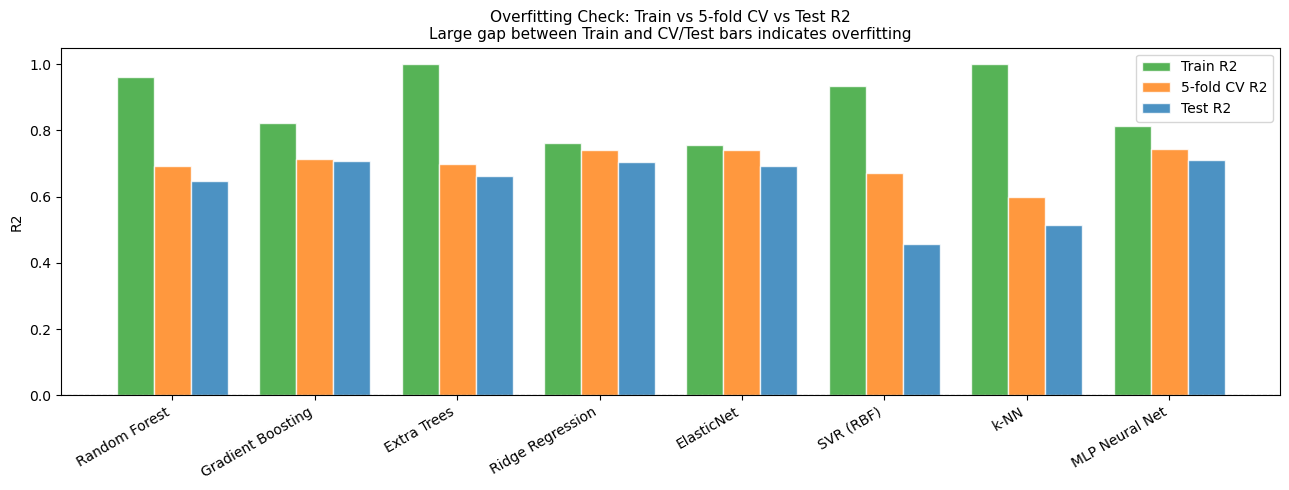

Overfitting gap = Train R2 - Test R2  (> 0.15 is a concern)

Model                  Train R2      CV R2    Test R2      Gap
--------------------------------------------------------------
Random Forest            0.9601     0.6940     0.6484   0.3117 <<< OVERFIT?
Gradient Boosting        0.8236     0.7129     0.7078   0.1158
Extra Trees              1.0000     0.6994     0.6610   0.3390 <<< OVERFIT?
Ridge Regression         0.7615     0.7414     0.7048   0.0568
ElasticNet               0.7567     0.7411     0.6935   0.0632
SVR (RBF)                0.9345     0.6713     0.4574   0.4772 <<< OVERFIT?
k-NN                     1.0000     0.5976     0.5149   0.4851 <<< OVERFIT?
MLP Neural Net           0.8141     0.7433     0.7114   0.1027


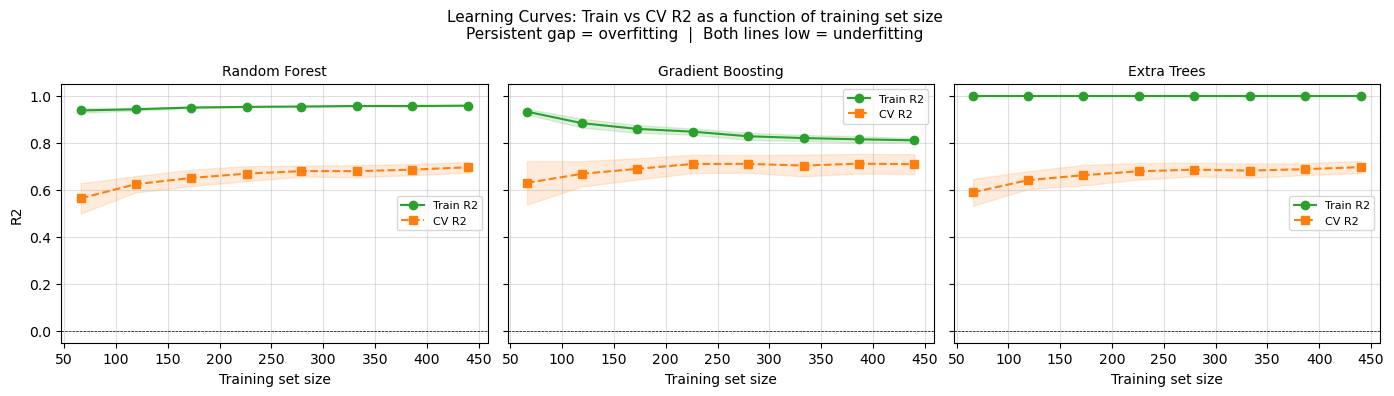

In [21]:
# -------------------------------------------------------
# 1) Grouped bar chart: Train vs CV vs Test R² for all models
# -------------------------------------------------------
model_names   = [m['Model'] for m in all_metrics]
test_r2_vals  = [m['R2'] for m in all_metrics]
cv_r2_vals    = [all_cv_r2.get(m, np.nan) for m in model_names]
train_r2_vals = [all_train_r2.get(m, np.nan) for m in model_names]

x     = np.arange(len(model_names))
width = 0.26

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - width, train_r2_vals, width, label='Train R2',    color='tab:green',  alpha=0.8, edgecolor='white')
ax.bar(x,         cv_r2_vals,    width, label='5-fold CV R2', color='tab:orange', alpha=0.8, edgecolor='white')
ax.bar(x + width, test_r2_vals,  width, label='Test R2',     color='tab:blue',   alpha=0.8, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=30, ha='right', fontsize=10)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_ylabel('R2')
ax.set_title(
    'Overfitting Check: Train vs 5-fold CV vs Test R2\n'
    'Large gap between Train and CV/Test bars indicates overfitting',
    fontsize=11,
)
ax.legend()
plt.tight_layout()
plt.show()

# Print a summary table
print('Overfitting gap = Train R2 - Test R2  (> 0.15 is a concern)\n')
print(f'{"Model":<20} {"Train R2":>10} {"CV R2":>10} {"Test R2":>10} {"Gap":>8}')
print('-' * 62)
for name, tr, cv, te in zip(model_names, train_r2_vals, cv_r2_vals, test_r2_vals):
    flag = ' <<< OVERFIT?' if (tr - te) > 0.15 else ''
    print(f'{name:<20} {tr:>10.4f} {cv:>10.4f} {te:>10.4f} {tr-te:>8.4f}{flag}')

# -------------------------------------------------------
# 2) Learning Curves for tree-based models
# -------------------------------------------------------
# n_estimators deliberately kept small here (200) so the curves run quickly.
lc_models = {
    'Random Forest': RandomForestRegressor(
        n_estimators=200, min_samples_leaf=best_leaf_rf,
        max_features='sqrt', n_jobs=-1, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=best_depth_gbr,
        subsample=0.8, random_state=42),
    'Extra Trees': ExtraTreesRegressor(
        n_estimators=200, min_samples_leaf=best_leaf_et,
        max_features='sqrt', n_jobs=-1, random_state=42),
}

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, (name, model) in zip(axes, lc_models.items()):
    train_sizes_abs, train_scores, val_scores = learning_curve(
        model, X, y,
        cv=5,
        scoring='r2',
        train_sizes=np.linspace(0.15, 1.0, 8),
        shuffle=True,
        random_state=42,
        n_jobs=-1,
    )
    tr_mean, tr_std = train_scores.mean(axis=1), train_scores.std(axis=1)
    vl_mean, vl_std = val_scores.mean(axis=1),   val_scores.std(axis=1)

    ax.plot(train_sizes_abs, tr_mean, 'o-', color='tab:green',  label='Train R2')
    ax.fill_between(train_sizes_abs, tr_mean - tr_std, tr_mean + tr_std,
                    alpha=0.15, color='tab:green')
    ax.plot(train_sizes_abs, vl_mean, 's--', color='tab:orange', label='CV R2')
    ax.fill_between(train_sizes_abs, vl_mean - vl_std, vl_mean + vl_std,
                    alpha=0.15, color='tab:orange')
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Training set size')
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.4)

axes[0].set_ylabel('R2')
fig.suptitle(
    'Learning Curves: Train vs CV R2 as a function of training set size\n'
    'Persistent gap = overfitting  |  Both lines low = underfitting',
    fontsize=11,
)
plt.tight_layout()
plt.show()

---
# Section: Model Comparison Summary

We compare all 8 models on three test-set metrics:

| Metric | Interpretation |
|---|---|
| **MAE** | Average absolute prediction error in magnitudes |
| **RMSE** | Root mean squared error — penalises large outliers more |
| **R²** | Fraction of $\Delta\mu$ variance explained (1 = perfect, 0 = null model) |

We also produce a **feature importance heatmap** comparing all algorithms.
Each row is **row-normalized** to $[0, 1]$ so that MDI importances, permutation importances,
and coefficient magnitudes are placed on a comparable *relative* scale.

> **Caveat:** Different importance methods measure different things.
> - *MDI* (tree models) can overweight high-cardinality or correlated features.
> - *Permutation importance* is model-agnostic and reflects actual test-set reliance,
>   but can be noisy on small datasets.
> - *Coefficients* (linear models) are only meaningful when the relationship is approximately linear.

=== Model Comparison Summary ===
                      MAE    RMSE      R2
Model                                    
Random Forest      0.1444  0.1934  0.6484
Gradient Boosting  0.1336  0.1763  0.7078
Extra Trees        0.1415  0.1899  0.6610
Ridge Regression   0.1312  0.1773  0.7048
ElasticNet         0.1350  0.1806  0.6935
SVR (RBF)          0.1781  0.2403  0.4574
k-NN               0.1760  0.2272  0.5149
MLP Neural Net     0.1271  0.1753  0.7114


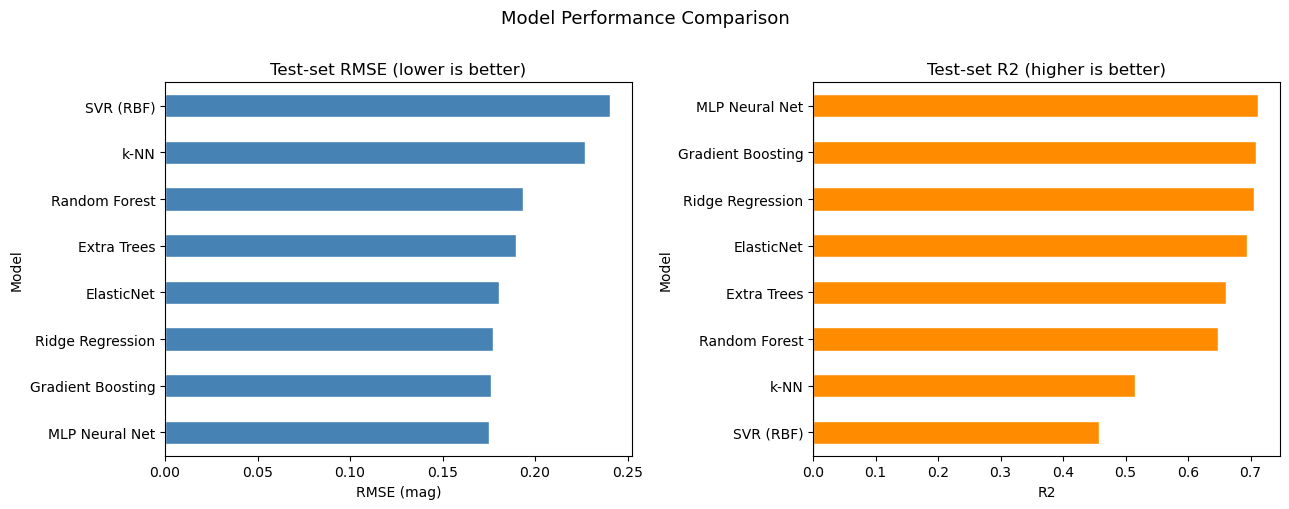

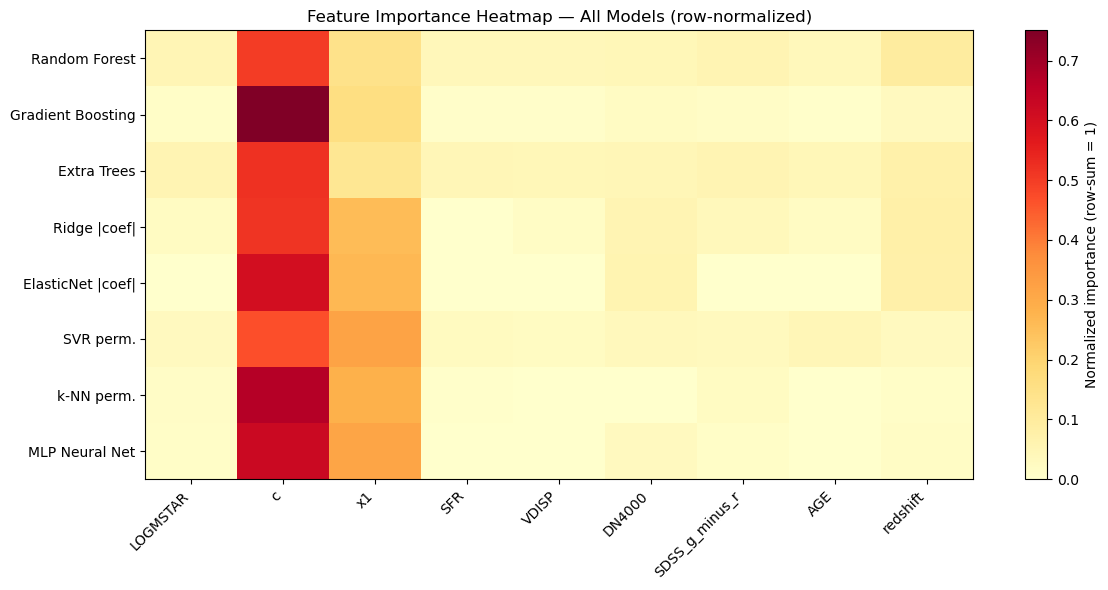

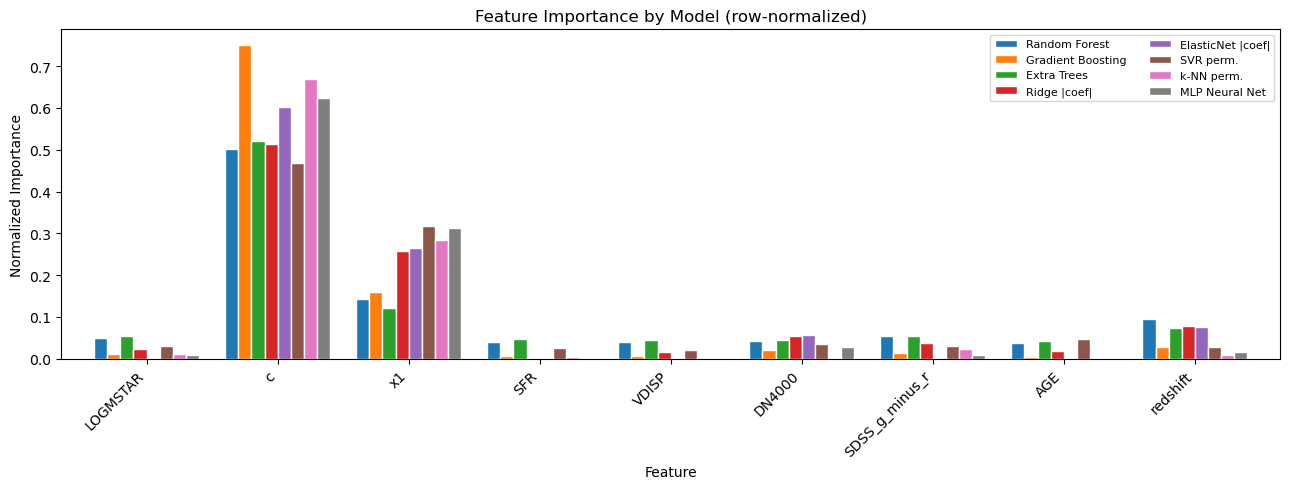

In [22]:
# -------------------------------------------------------
# Metrics table
# -------------------------------------------------------
metrics_df = pd.DataFrame(all_metrics).set_index('Model')
print('=== Model Comparison Summary ===')
print(metrics_df.round(4).to_string())

# -------------------------------------------------------
# Side-by-side bar charts: RMSE and R2
# -------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

metrics_df['RMSE'].sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title('Test-set RMSE (lower is better)')
axes[0].set_xlabel('RMSE (mag)')

metrics_df['R2'].sort_values().plot(
    kind='barh', ax=axes[1], color='darkorange', edgecolor='white'
)
axes[1].set_title('Test-set R2 (higher is better)')
axes[1].set_xlabel('R2')
axes[1].axvline(0, color='black', linewidth=0.8)

plt.suptitle('Model Performance Comparison', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# -------------------------------------------------------
# Feature importance heatmap (all models, row-normalized)
# -------------------------------------------------------
fi_compare = pd.DataFrame(fi_store).T          # rows = models, cols = features
fi_compare = fi_compare[feature_cols]           # enforce consistent column order
fi_compare = fi_compare.clip(lower=0)           # clip small negative permutation importances
row_sums = fi_compare.sum(axis=1)
fi_norm = fi_compare.div(row_sums.where(row_sums > 0, 1), axis=0)  # row-normalize

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(fi_norm.values, aspect='auto', cmap='YlOrRd', vmin=0)
ax.set_xticks(range(len(feature_cols)))
ax.set_xticklabels(feature_cols, rotation=45, ha='right', fontsize=10)
ax.set_yticks(range(len(fi_norm)))
ax.set_yticklabels(fi_norm.index, fontsize=10)
plt.colorbar(im, ax=ax, label='Normalized importance (row-sum = 1)')
ax.set_title('Feature Importance Heatmap — All Models (row-normalized)', fontsize=12)
plt.tight_layout()
plt.show()

# -------------------------------------------------------
# Grouped bar chart: per-feature importance by model
# -------------------------------------------------------
fi_norm.T.plot(
    kind='bar',
    figsize=(13, 5),
    edgecolor='white',
    width=0.8,
)
plt.title('Feature Importance by Model (row-normalized)', fontsize=12)
plt.xlabel('Feature')
plt.ylabel('Normalized Importance')
plt.xticks(rotation=45, ha='right')
plt.legend(loc='upper right', fontsize=8, ncol=2)
plt.tight_layout()
plt.show()